# Diffraction around arbitrary apertures

## TODO
- I think the computation might not be fully correct
- Need to try and make this more accurate

## Load libraries

In [1]:
# Load libraries
import numpy as np

# Plotting / graphics
import matplotlib.pyplot as plt

# Set figure resolution
plt.rcParams['figure.dpi'] = 200

# Complex numbers
import cmath

## Parameters

In [16]:
# Wavelength of the incident light
wavelength = 0.1

# Distance between aperture and screen
distance_to_screen = 10

# Grid size describing the aperture
aperture_grid_size = 0.0125

# Grid size of the screen
screen_grid_size = 0.01

# Size of the screen to render
screen_size = 0.75

## Amplitude Function

In [3]:
def amplitude(distance_sqr):
    return np.cos(2 * np.pi * distance_sqr**0.5 / wavelength) / (
        4 * np.pi * distance_sqr
    )

def complex_amplitude(distance_sqr):
    return np.exp(1j * 2 * np.pi * distance_sqr**0.5 / wavelength) / 4*np.pi*distance_sqr

## Distance to Screen

In [4]:
def distance_sqr_to_screen(aperture_position, screen_position, screen_distance):
    return (
        (aperture_position[0] - screen_position[0]) ** 2
        + (aperture_position[1] - screen_position[1]) ** 2
        + screen_distance**2
    )

## Aperture Class

In [5]:
class Aperture:
    def __init__(self, bounds, aperture, aperture_grid_size=aperture_grid_size):
        # Bounds provided as a [ [min_x, max_x], [min_y, max_y] ]
        self.bounds = bounds
        self.aperture = aperture
        self.aperture_points_x = np.linspace(
            bounds[0][0],
            bounds[0][1],
            int((bounds[0][1] - bounds[0][0]) / aperture_grid_size),
        )
        self.aperture_points_y = np.linspace(
            bounds[1][0],
            bounds[1][1],
            int((bounds[1][1] - bounds[1][0]) / aperture_grid_size),
        )
        self.grid = []
        for x in self.aperture_points_x:
            for y in self.aperture_points_y:
                if aperture(x, y) == 1:
                    self.grid.append([x, y])

## Intensity at point

In [6]:
def intensity_on_screen(aperture, screen_distance, screen_position):
    # Will return a single value denoting the intensity on the screen
    amp = 0
    for point in aperture.grid:
        distance_sqr = distance_sqr_to_screen(point, screen_position, screen_distance)
        amp += amplitude(distance_sqr)
    return amp**2

def complex_intensity_on_screen(aperture, screen_distance, screen_position):
    amp = 0
    for point in aperture.grid:
        distance_sqr = distance_sqr_to_screen(point, screen_position, screen_distance)
        amp += complex_amplitude(distance_sqr)
    return 0.5 * abs(amp)**2

## Intensity on whole screen

In [7]:
# Simulate over whole screen
def simulate(aperture, screen_size, screen_distance):
    screen_grid = [
        [x, y]
        for x in np.linspace(0, screen_size / 2, int(screen_size / screen_grid_size))
        for y in np.linspace(0, screen_size / 2, int(screen_size / screen_grid_size))
    ]
    screen_display = []

    for point in screen_grid:
        screen_brightness = complex_intensity_on_screen(aperture, screen_distance, point)
        screen_display.append(screen_brightness)

    return np.reshape(
        screen_display,
        [
            int(screen_size / screen_grid_size),
            int(screen_size / screen_grid_size),
        ],
    ).T

## Graphics - display results

In [8]:
def display_result(aperture, screen_size=screen_size, distance_to_screen=distance_to_screen):
    result = simulate(aperture, screen_size, distance_to_screen)
    top = np.concatenate((np.fliplr(result[:, 1:]), result), axis=1)
    full = np.concatenate((np.flipud(top[1:, :]), top), axis=0)
    plt.imshow(full, cmap="gray")
    plt.show()

## Execute - Wide double slit aperture

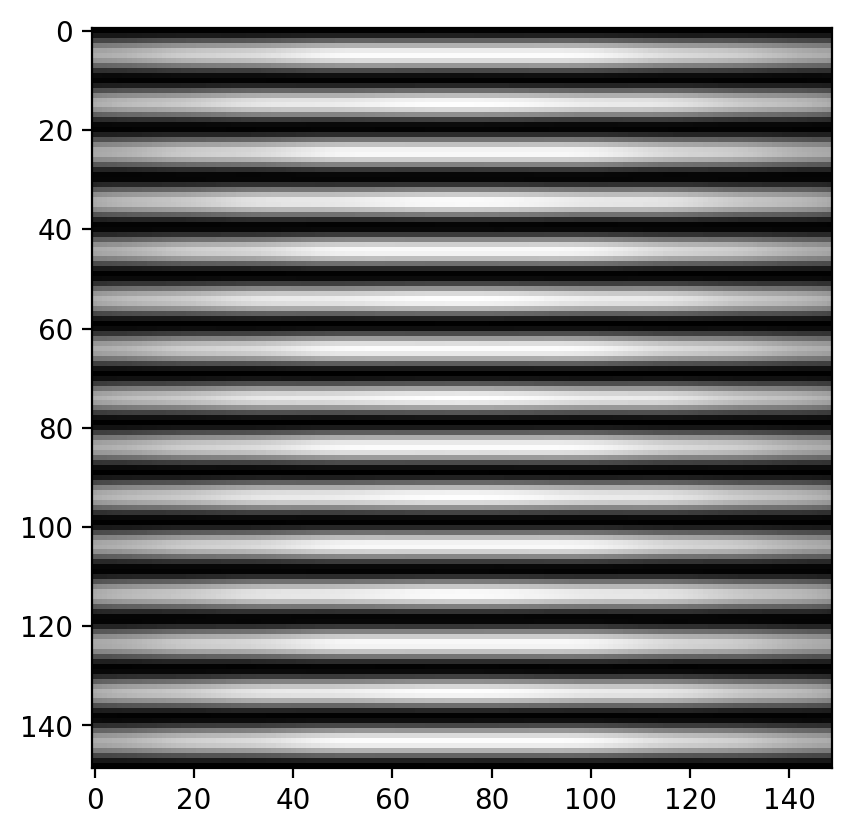

In [10]:
# Bounds of the aperture
wide_double_bounds = [[-0.3, 0.3], [-1, 1]]

# Function defining the aperture
def wide_double(x, y):
    if -0.3 <= x <= -0.2 or 0.2 <= x <= 0.3:
        return 1
    return 0

# Instance of the wide double aperture
wide_double_aperture = Aperture(wide_double_bounds, wide_double)

# Run simulation
display_result(wide_double_aperture)

## Execute - circular aperture

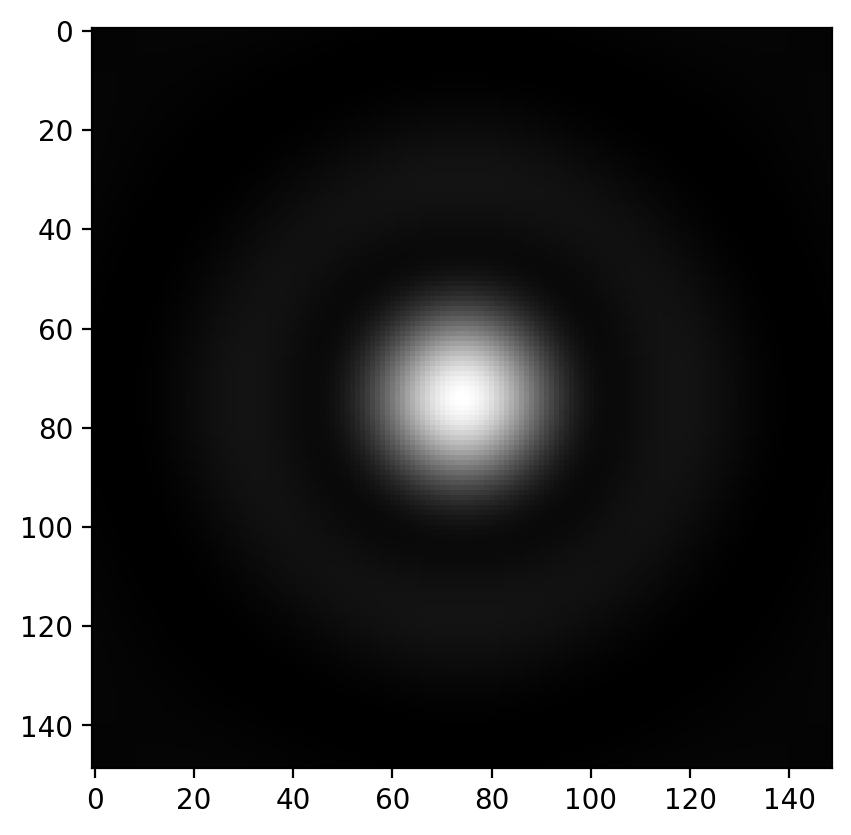

In [11]:
# Bounds of the aperture
radius = 0.2
circular_bounds = [[-radius, radius], [-radius, radius]]

# Function defining the aperture
def circular(x, y):
    return 1 if x**2 + y**2 <= radius**2 else 0

# Instance of the circular aperture
circular_aperture = Aperture(circular_bounds, circular)

# Run simulation
display_result(circular_aperture)

## Execute - square aperture

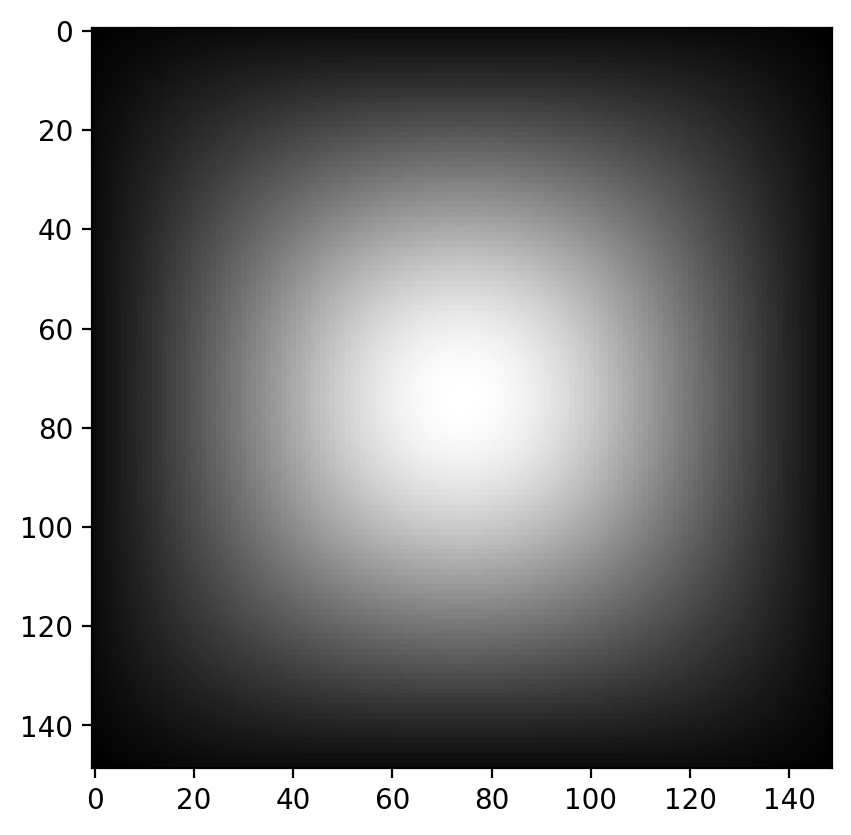

In [17]:
# Define bounds of the square
half_length = 0.05
square_bounds = [[-half_length, half_length], [-half_length, half_length]]

# Function defining the aperture - could just always return a 1
def square(x, y):
    return 1

# Instance of the square aperture
square_aperture = Aperture(square_bounds, square)

# Run simulation
display_result(square_aperture)